In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import joblib

In [3]:
df = pd.read_csv('agromap_professional_dataset_v4.csv')

In [4]:
print("Перші 5 рядків датасету:")
print(df.head())

Перші 5 рядків датасету:
  soil_type crop_type  ndvi_early  ndvi_mid  ndvi_late  rain_sum_early  \
0     chalk  soybeans       0.288     0.643      0.369           42.57   
1      silt    barley       0.260     0.786      0.418           76.56   
2      peat    barley       0.219     0.731      0.358           63.91   
3     sandy      corn       0.237     0.684      0.518           75.08   
4      silt      oats       0.277     0.721      0.476           61.08   

   rain_sum_mid  rain_sum_late  temp_sum_early  temp_sum_mid  temp_sum_late  \
0        109.63          54.75          385.83        892.72         756.85   
1        129.05          49.85          381.69        949.91         739.91   
2        123.48          56.72          344.90        891.86         615.39   
3         92.16          46.52          319.25        820.38         782.22   
4        109.13          50.51          375.31        945.49         773.92   

   yield  
0   4.92  
1   5.95  
2   6.19  
3   9.99  


In [5]:
X = df.drop(columns=['yield'])
y = df['yield']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print("Дані успішно розділено!")
print(f"Тренувальна вибірка: {X_train.shape[0]} рядків")
print(f"Валідаційна вибірка: {X_test.shape[0]} рядків")

Дані успішно розділено!
Тренувальна вибірка: 6400 рядків
Валідаційна вибірка: 1600 рядків


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [9]:
categorical_features = ['soil_type', 'crop_type']

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [11]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=4, random_state=42, n_jobs=-1))
])

In [ ]:
print("навчання моделі")

Починаємо навчання моделі


In [13]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [14]:
y_pred = pipeline.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
print("\n--- Результати оцінки моделі ---")
print(f"Помилка MAE (середнє відхилення в тоннах): {mae:.4f} т/га")
print(f"Помилка RMSE: {rmse:.4f}")
print(f"Точність моделі R² (коефіцієнт детермінації): {r2:.4f} (тобто {r2*100:.2f}%)")


--- Результати оцінки моделі ---
Помилка MAE (середнє відхилення в тоннах): 0.2757 т/га
Помилка RMSE: 0.3659
Точність моделі R² (коефіцієнт детермінації): 0.9811 (тобто 98.11%)


In [17]:
model_filename = 'yield_forecast_pipeline.pkl'
joblib.dump(pipeline, model_filename)

print(f"\n[УСПІХ] Пайплайн моделі збережено у файл: '{model_filename}'")


[УСПІХ] Пайплайн моделі збережено у файл: 'yield_forecast_pipeline.pkl'


In [20]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Рахуємо прогнози для ТРЕНУВАЛЬНИХ даних
y_train_pred = pipeline.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("=== ПОРІВНЯННЯ МЕТРИК ===")
print(f"Train R²: {r2_train:.4f}  |  Test R²: {r2:.4f}")
print(f"Train MAE: {mae_train:.4f} |  Test MAE: {mae:.4f}")
print(f"Train RMSE: {rmse_train:.4f} |  Test RMSE: {rmse:.4f}\n")



=== ПОРІВНЯННЯ МЕТРИК ===
Train R²: 0.9895  |  Test R²: 0.9811
Train MAE: 0.2055 |  Test MAE: 0.2757
Train RMSE: 0.2641 |  Test RMSE: 0.3659



=== CROSS VALIDATION RESULTS ===
R²: 0.9793 ± 0.0012
MAE: 0.2807 ± 0.0055
RMSE: 0.3719 ± 0.0129


=== ТАБЛИЦЯ ВАЖЛИВОСТІ ОЗНАК ===
            Feature  Importance
     crop_type_corn    0.410301
      temp_sum_late    0.150050
       temp_sum_mid    0.130932
       rain_sum_mid    0.060555
     rain_sum_early    0.035918
    crop_type_wheat    0.031530
      rain_sum_late    0.029203
   soil_type_gravel    0.028040
           ndvi_mid    0.027312
     temp_sum_early    0.020285
          ndvi_late    0.016752
    soil_type_sandy    0.015422
   crop_type_barley    0.014497
      crop_type_rye    0.012000
     soil_type_loam    0.008247
     crop_type_oats    0.004953
         ndvi_early    0.001796
     soil_type_clay    0.001000
 crop_type_rapeseed    0.000624
 crop_type_soybeans    0.000244
crop_type_sunflower    0.000157
    soil_type_chalk    0.000106
     soil_type_silt    0.000044
     soil_type_peat    0.000034




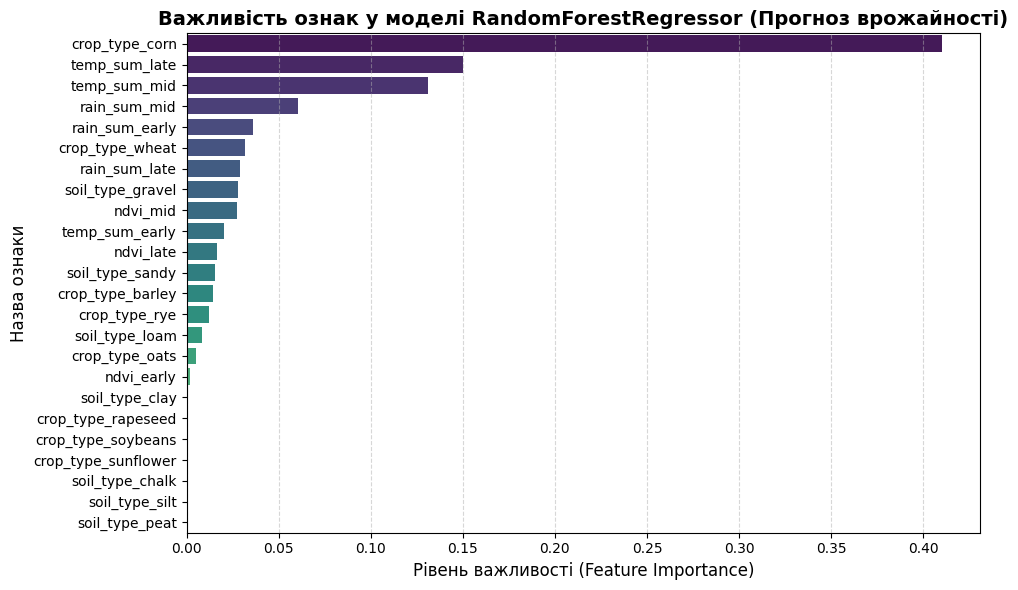

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = pipeline.named_steps['regressor'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df['Feature'] = (feature_importance_df['Feature']
                                     .str.replace('cat__', '', regex=False)
                                     .str.replace('remainder__', '', regex=False))

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("=== ТАБЛИЦЯ ВАЖЛИВОСТІ ОЗНАК ===")
print(feature_importance_df.to_string(index=False))
print("\n" + "="*30 + "\n")

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature', 
    legend=False
)

plt.title('Важливість ознак у моделі RandomForestRegressor (Прогноз врожайності)', fontsize=14, fontweight='bold')
plt.xlabel('Рівень важливості (Feature Importance)', fontsize=12)
plt.ylabel('Назва ознаки', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()